In [1]:
import torch
from nns.memorygraphs.graph_memorypool import MemoryConfig, Controller, GmemoryI, GmemoryII, Gposition
from nns.cnns.features import RetinaModel, MultiScaleFeatureBank
from trail.pic_tools import image_to_tensor, tensor_to_image_1channel

# 1. 初始化配置与核心模块
cfg = MemoryConfig()
cfg.H = 512
cfg.W = 512
# 如果使用 GPU，可以解注并设置：
# cfg.device = torch.device('cuda:0')

gmem_i = GmemoryI()
gmem_ii = GmemoryII(cfg)
gpos = Gposition(cfg)
controller = Controller(cfg)

# 2. 视觉前端特征提取器初始化
retina = RetinaModel(edge_apply_gaussian=True, edge_gauss_kernel_size=5, edge_gauss_sigma=1.0)
msbank = MultiScaleFeatureBank(scales=[1.0, 2.0, 4.0], base_sigma=1.0)

In [2]:
# 3. 加载测试图像
image_path = 'picture/OIP-C.jpg'
tensor, original_image = image_to_tensor(image_path)
B, C, W, H = tensor.shape # 注意: 根据 image_to_tensor 返回，检查宽高顺序

# 4. 提取CNN特征
_, grad, hue, _, _, cropped = retina(tensor, center_x=-1, center_y=-1)
cur, asp, ori = msbank(cropped)

# 格式化各个子空间张量，确保它们是 [B, C_m, H, W]
# ※请注意：这里需要依赖您 CNN 呈递结果的具体形状，若 grad/hue 最后带有 channel=2 等，需在这里做维度重排或取模

grad = grad.squeeze(1).permute(0, 3, 1, 2)
X_subspaces = {
    0: grad,  # Modality 0: Edge
    1: hue,   # Modality 1: Hue
    # 可后续按需加入:
    # 2: cur, # Modality 2: Curvature 等
}

# 将张量移动到对应执行设备
for k, v in X_subspaces.items():
    X_subspaces[k] = v.to(cfg.device)

In [ ]:
# 5. 初始化控制器底层兴趣图
controller.initialize_interest_map(X_subspaces, W, H, 3)
print(f"=== 初始控制器状态 ===")
print(f"Fixation Point: {controller.fixation_point}")
print(f"State: {controller.state.name}")
print("-" * 50)

# 6. 单步运行调度与打印
max_steps = 100  # 设定最大迭代步数
route = []
img = []
img2 = []

for step in range(1, max_steps + 1):
    # 执行单步：Top-Down 匹配与 Bottom-Up 眼跳
    controller.run_step(X_subspaces, gmem_i, gmem_ii, gpos)
    
    # 提取当前信息
    current_state = controller.state.name
    fx, fy = controller.fixation_point
    num_gi_nodes = len(gmem_i.nodes)
    num_gii_nodes = len(gmem_ii.semantic_nodes)
    
    # 打印单步调试数据
    print(f"Step {step:03d} | "
          f"State: {current_state:<12} | "
          f"Fixation: ({fx:4.1f}, {fy:4.1f}) | "
          f"GI Nodes: {num_gi_nodes:3d} | "
          f"GII Nodes: {num_gii_nodes:3d}")

    route.append(fx)
    route.append(fy)
    
    if step in [20,40,60,80,100]:
      img.append(tensor_to_image_1channel(controller.interest_map))
      img2.append(tensor_to_image_1channel(controller.base_interest))


=== 初始控制器状态 ===
Fixation Point: (256, 256)
State: REVIEW
--------------------------------------------------
Step 001 | State: LEARN        | Fixation: (368.0, 246.0) | GI Nodes:   2 | GII Nodes:   1
Step 002 | State: LEARN        | Fixation: (463.0, 220.0) | GI Nodes:   3 | GII Nodes:   2
Step 003 | State: LEARN        | Fixation: (488.0, 284.0) | GI Nodes:   3 | GII Nodes:   3
Step 004 | State: LEARN        | Fixation: (488.0, 284.0) | GI Nodes:   3 | GII Nodes:   4
Step 005 | State: LEARN        | Fixation: (488.0, 284.0) | GI Nodes:   3 | GII Nodes:   4
Step 006 | State: LEARN        | Fixation: (488.0, 284.0) | GI Nodes:   3 | GII Nodes:   4
Step 007 | State: LEARN        | Fixation: (488.0, 284.0) | GI Nodes:   3 | GII Nodes:   4
Step 008 | State: LEARN        | Fixation: (488.0, 284.0) | GI Nodes:   3 | GII Nodes:   4
Step 009 | State: LEARN        | Fixation: (453.0, 285.0) | GI Nodes:   3 | GII Nodes:   4
Step 010 | State: LEARN        | Fixation: (491.0, 284.0) | GI Nodes:   3

# Trail

In [4]:
from trail.pic_tools import *
from trail.matrix_tools import *
# from trail.viewrouteDraw import *
# import random
# from trail.foveated_visualization1 import visualize_step
import glob
import os

# print(controller.interest_map)

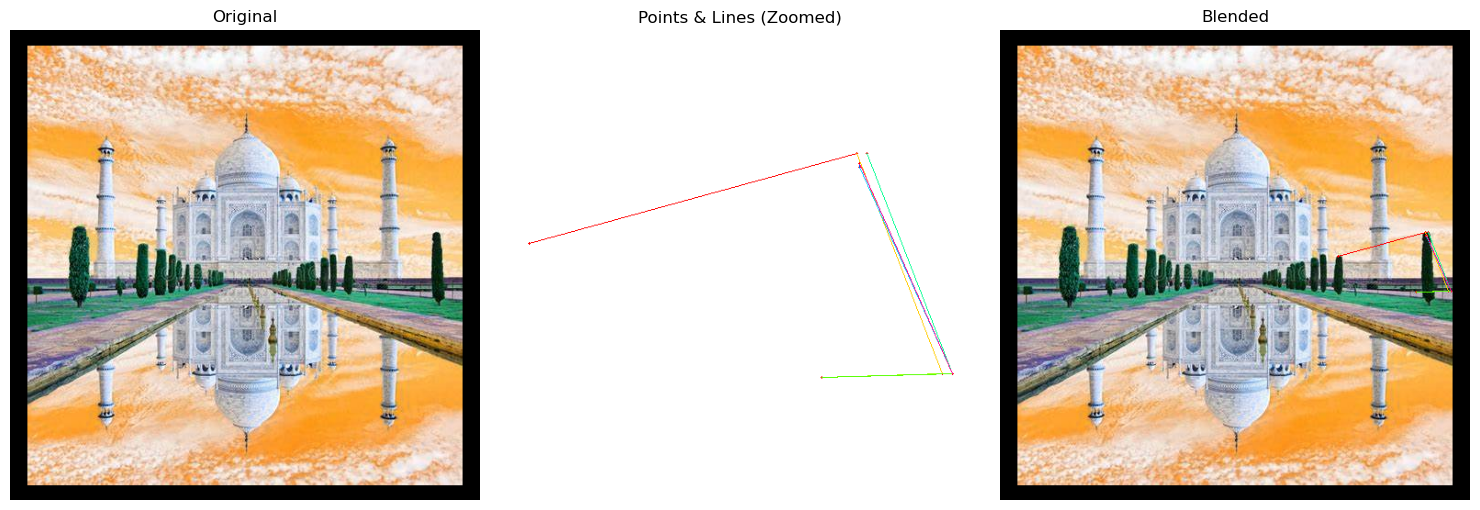

In [5]:
from trail.viewrouteDraw import debug_mark_advanced
import cv2
import matplotlib.pyplot as plt

debug_mark_advanced(
    image_input=cropped,
    points=route,
    point_size=1,
    line_thickness=1,
    draw_points=True,
    draw_lines=True,
    gradient_lines=True,
    start_hue=0.0,           # 从红色开始
    background_color=(255,255,255),  # 白色背景
    display_in_notebook=True
)



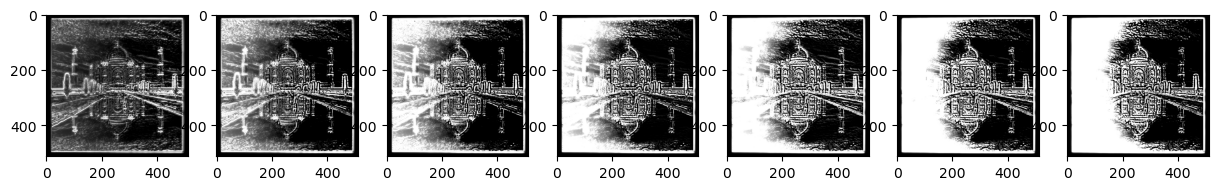

In [6]:
picnum = len(img)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, img):
    ax.imshow(image)

plt.show()

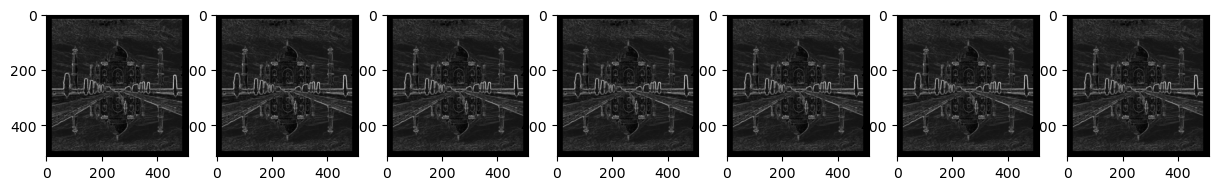

In [7]:
picnum = len(img2)

fig, axes = plt.subplots(1, picnum, figsize=(15, 5))

for ax, image in zip(axes, img2):
    ax.imshow(image)

plt.show()

# folder pic

In [ ]:
folder_path = '/home/p/code/ILSVRC/Data/DET/train/ILSVRC2014_train_0006'

# image_paths = glob.glob(os.path.join(folder_path, '*.JPEG'))

image_paths = glob.iglob(folder_path + '/*.JPEG')
pic = 1
for image_path in image_paths:
    print(f"Picture {pic}")
    pic += 1
    
    tensor, oringinal_image = image_to_tensor(image_path)
    B, C, W, H = tensor.shape

    # retina_out = retina(tensor, center_x = -1, center_y = -1)
    _, grad, hue, _, _, cropped = retina(tensor, center_x = -1, center_y = -1)
    # msfb_out = msbank(cropped)
    cur, asp, ori = msbank(cropped)


    step = 1
    mc.handle_new_view({'grad': grad, 'hue': hue, 'curvature': cur, 'aspect': asp, 'orientation': ori})
    step += 1

    while step < 200:
        mc.handle_new_view({'grad': grad, 'hue': hue, 'curvature': cur, 'aspect': asp, 'orientation': ori})
        step += 1

    print(f"Step {step}, graph1 nodes in total = {mc.graphI.graphI[0]._next_proto_id} ")
    print(f"Step {step}, graph2 nodes in total = {mc.graphII.next_graph2_id} ")

    mc.graphI.reset_all_buckets()
    # if 5 == pic:
    #     break



# trail tools

In [ ]:
mode, Nactivated_nodes, Nactive_protos, center = fm.run_one_step(grad, hue, cur, asp, ori, reset_image=True)

print("Step 1 mode:", mode, ", center:", center, ", #Nactivated_nodes:", Nactivated_nodes, ", #Nactive_protos:", Nactive_protos)
print(fm.graphI.saccade.mode)

In [ ]:
i = 2
while mode != 'end' and i < 200:
    mode, Nactivated_nodes, Nactive_protos, center = fm.run_one_step(grad, hue, cur, asp, ori, reset_image=False)
    print(f"Step {i}: mode={mode}, center={center}, #Nactivated_nodes={Nactivated_nodes}, #Nactive_protos:={Nactive_protos}")
    print(fm.graphI.saccade.mode)
    i += 1


In [ ]:
print(len(fm.graphII.graph2_nodes))
print(len(fm.graphII.graph2_edges))
print(fm.graphII.next_graph2_id)

In [ ]:

print('0', fm.graphI.graphI[0]._next_node_id, fm.graphI.graphI[0]._next_proto_id)
print('1', fm.graphI.graphI[1]._next_node_id, fm.graphI.graphI[1]._next_proto_id)
print('2', fm.graphI.graphI[2]._next_node_id, fm.graphI.graphI[2]._next_proto_id)
print('3', fm.graphI.graphI[3]._next_node_id, fm.graphI.graphI[3]._next_proto_id)
print('4', fm.graphI.graphI[4]._next_node_id, fm.graphI.graphI[4]._next_proto_id)

In [ ]:
import torch
from nns.memorygraphs.graph_memorypool import MemoryConfig, Controller, GmemoryI, GmemoryII, Gposition
from nns.cnns.features import RetinaModel, MultiScaleFeatureBank
from trail.pic_tools import image_to_tensor

# 1. 初始化配置与核心模块
cfg = MemoryConfig()
cfg.H = 512
cfg.W = 512
# 如果使用 GPU，可以解注并设置：
# cfg.device = torch.device('cuda:0')

gmem_i = GmemoryI()
gmem_ii = GmemoryII(cfg)
gpos = Gposition(cfg)
controller = Controller(cfg)

# 2. 视觉前端特征提取器初始化
retina = RetinaModel(edge_apply_gaussian=True, edge_gauss_kernel_size=5, edge_gauss_sigma=1.0)
msbank = MultiScaleFeatureBank(scales=[1.0, 2.0, 4.0], base_sigma=1.0)

# 3. 加载测试图像
image_path = 'picture/OIP-C.jpg'
tensor, original_image = image_to_tensor(image_path)
B, C, W, H = tensor.shape # 注意: 根据 image_to_tensor 返回，检查宽高顺序

# 4. 提取CNN特征
_, grad, hue, _, _, cropped = retina(tensor, center_x=-1, center_y=-1)
cur, asp, ori = msbank(cropped)

# 格式化各个子空间张量，确保它们是 [B, C_m, H, W]
# ※请注意：这里需要依赖您 CNN 呈递结果的具体形状，若 grad/hue 最后带有 channel=2 等，需在这里做维度重排或取模

grad = grad.squeeze(1).permute(0, 3, 1, 2)
X_subspaces = {
    0: grad,  # Modality 0: Edge
    1: hue,   # Modality 1: Hue
    # 可后续按需加入:
    # 2: cur, # Modality 2: Curvature 等
}

# 将张量移动到对应执行设备
for k, v in X_subspaces.items():
    X_subspaces[k] = v.to(cfg.device)

# 5. 初始化控制器底层兴趣图
controller.initialize_interest_map(X_subspaces)
print(f"=== 初始控制器状态 ===")
print(f"Fixation Point: {controller.fixation_point}")
print(f"State: {controller.state.name}")
print("-" * 50)

# 6. 单步运行调度与打印
max_steps = 200  # 设定最大迭代步数
for step in range(1, max_steps + 1):
    # 执行单步：Top-Down 匹配与 Bottom-Up 眼跳
    controller.run_step(X_subspaces, gmem_i, gmem_ii, gpos)
    
    # 提取当前信息
    current_state = controller.state.name
    fx, fy = controller.fixation_point
    num_gi_nodes = len(gmem_i.nodes)
    num_gii_nodes = len(gmem_ii.semantic_nodes)
    
    # 打印单步调试数据
    print(f"Step {step:03d} | "
          f"State: {current_state:<12} | "
          f"Fixation: ({fx:4.1f}, {fy:4.1f}) | "
          f"GI Nodes: {num_gi_nodes:3d} | "
          f"GII Nodes: {num_gii_nodes:3d}")